In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from variation_relax import preprocess_mesh, relax_bending
from plot import plot_dots
import os


file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
n_vertices = 100
s_val = 10

coords, original_coords = preprocess_mesh(file, resample_geometry=True, n_vertices=n_vertices, s_val = s_val)

params = {
    "Kb": 10,
    "Ksg": 10,
    "Ksl": 10,
    "dt": 1e-5,
    # "n_iter": int(8e2),
    "n_iter": int(1e5),
    "boundary": "pinned",
}
relaxed_coords = relax_bending(coords, **params)

file_path = os.path.join(f"dat/model_case", f"coords_n{n_vertices:03d}_s{s_val}.npz")
np.savez(file_path, coords = relaxed_coords, original_coords = original_coords)



Energy relaxation:   0%|          | 0/100000 [00:00<?, ?it/s]

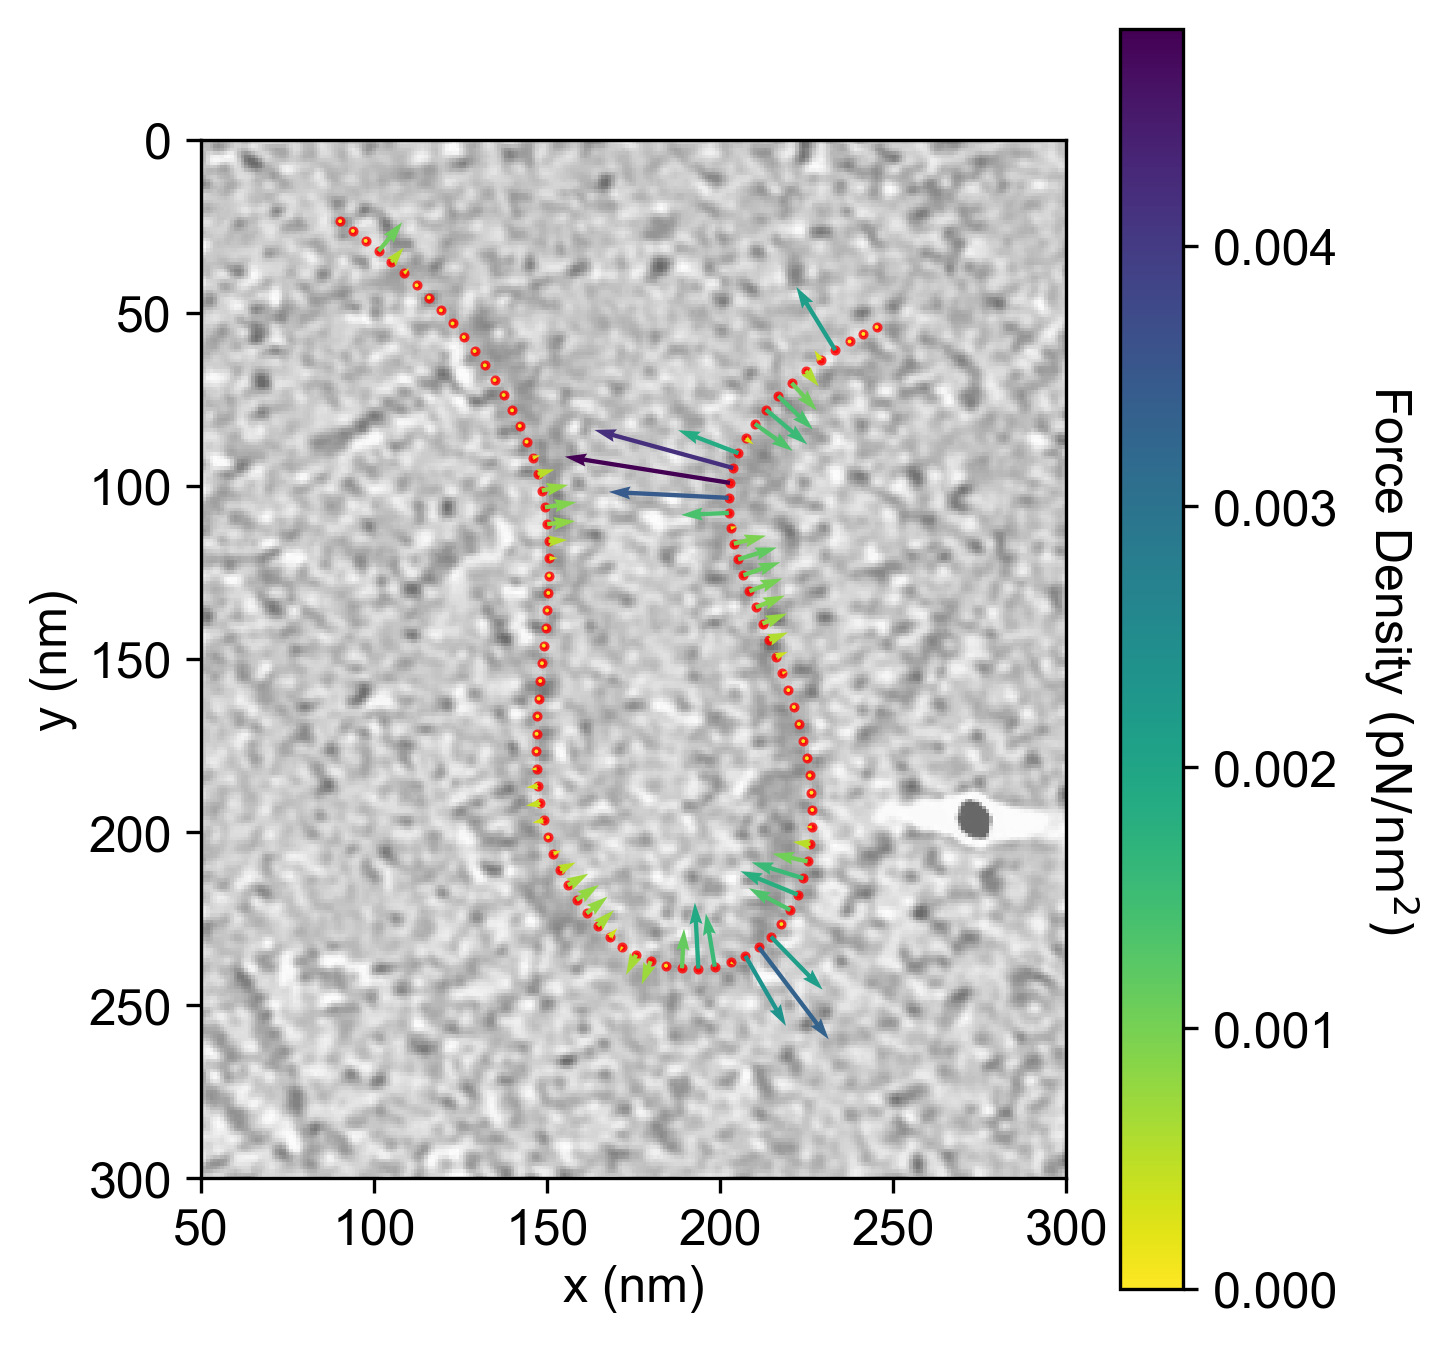

In [7]:
import numpy as np
import numpy.typing as npt
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from variation_run import get_force_density
from automembrane.energy import OpenPlaneCurveMaterial
from automembrane.geometry import OpenPlaneCurveGeometry
from plot import load_image, shift_coords, resize_image

def plot_coord_force(
    file_stem: str,
    coord: npt.NDArray[np.float64],
    force: npt.NDArray[np.float64],
    ax,
    xlim=None,
    ylim=(300, -50),
    scale_factor: float = 0.003,
):
    coord_x, coord_y = shift_coords(coord)
    
    image = load_image(file_stem)
    resized_image = resize_image(image, 0.6/1.1)
    
    ax.imshow(resized_image, cmap='gray', alpha=0.6)

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # Scatter plot of the coordinates
    ax.scatter(coord_x, coord_y, color='red', s=2, alpha=0.8)

    # Compute force magnitudes and plot with quiver
    f_mag = np.linalg.norm(force, axis=1)
    q = ax.quiver(
        coord_x,
        coord_y,
        -force[:, 0],
        -force[:, 1],
        f_mag,
        cmap=mpl.cm.viridis_r,
        # color="red",
        angles="xy",
        scale=scale_factor,
        scale_units="xy",
        width=0.005,
    )
    ax.set_xlabel('x (nm)')
    ax.set_ylabel('y (nm)')


    cbar = fig.colorbar(
        q,
        ax=ax,
    )
    cbar.ax.get_yaxis().labelpad = 20
    cbar.ax.set_ylabel(r"Force Density $\mathrm{(pN/nm^2)}$", rotation=270)




file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
parameters = {
    "Kb": 100/4,  # Bending modulus (pN um; original 1e-19 J)
    "Ksg": 0.05,  # Global stretching modulus (pN um/um^2; original 0.05 mN/m)
    "Ksl": 0,     # Regularization modulus (pN um; 0), 
    "boundary": "fixed"
}

n_vertices = 100
s_val = 100

fig, ax = plt.subplots(figsize=(5, 5))
        
data = np.load(f"dat/model_case/coords_n{n_vertices:03d}_s{s_val}.npz")
coords = data['coords']
forces = get_force_density(parameters, coords)
# force_sum = forces[0,:] + forces[1,:]
force_sum = forces[0,:]

plot_coord_force(
    file.stem, 
    coords,
    force_sum,
    ax=ax,
    xlim=(50, 300), 
    ylim=(300, 0), 
    scale_factor=0.0001,
)

# Adjust layout for better spacing between plots
plt.tight_layout()
# plt.savefig(f"figures/model_case/force_dist_{n_vertices:03d}_s{s_val}.png", dpi=300)
plt.show()

In [26]:
print(np.max(np.sqrt(force_sum[:,1]**2 + force_sum[:,0]**2)))

0.006459006391227192
